# Neural Network Taxi Demand Prediction -- Community Area, 1-Hour Resolution

**Same pooled-NN approach as `03.03`, at a finer time resolution (1h vs. 4h) -- the NN
counterpart of [03.02_prediction_svm_CA_1h.ipynb](03.02_prediction_svm_CA_1h.ipynb).**

- Same 77 community areas; 1h windows means ~4x the rows and heavier zero-inflation.
- **Why this notebook exists**: a genuine scaling stress test for NN training cost, not just a
  resolution swap -- same reasoning `03.02` gives on the SVM side.
- Mirrors `03.03` section-for-section; only what's new or different at 1h is called out here --
  see `03.03` for the underlying reasoning (log-scale target, skill score, why pooled,
  validation strategy).
- **Course constraint**: same as `03.03` -- no lagged/autoregressive demand features.

**Notebook structure**:
1. Data loading (1) & panel construction (2) & features (3)
2. Profile baseline (4)
3. Shallow NN, feature importance (5)
4. NN architecture & hyperparameter search (6)
5. Results -- model comparison, per-area performance (7)
6. Export results (8)
7. Shortfalls & honest limitations (9)
8. Outlook (10)

## Validation Strategy

24 hourly profile-baseline buckets instead of 4h's 6 -- a finer, harder-to-beat reference at
this resolution (same effect `03.02` documents on the SVM side). Everything else is unchanged
from the corrected `03.03`: chronological holdout, a **day-blocked** early-stopping split,
early stopping and model selection on the **demand-weighted** count-space metrics (weighted RMSE
for stopping, demand-weighted skill for selection), and a **full-train refit** of the reported
model. The one runtime shortcut specific to this notebook: the Deep NN architecture is **not
re-searched** here -- it reuses the config `03.03` selected and exported (see Section 6).


In [1]:
import time
import pathlib
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import contextily as ctx
import holidays

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TAXI_DATA_PATH       = "../../data/chicago_taxi_2024_2026_clean.parquet"
WEATHER_DATA_PATH    = "../../data/chicago_weather_2024_2026_hourly.csv"
COMMUNITY_AREAS_PATH = "../../data/community_areas_chicago.geojson"

# Data range covered by the cleaned parquet (June 2026+ excluded: portal reporting lag)
DATA_START    = pd.Timestamp("2024-01-01")
DATA_END_EXCL = pd.Timestamp("2026-06-01")

# Chronological split: train 2024-2025 (two full years), test Jan-May 2026 -- identical to 03.03
TRAIN_END = pd.Timestamp("2026-01-01")

# Evaluation week for baseline comparison
EVAL_WEEK_START = pd.Timestamp("2026-03-02")
EVAL_WEEK_END   = EVAL_WEEK_START + pd.Timedelta(days=7)

FREQ = "1h"  # community-area resolution at 1h windows -- see 03.03 for the 4h version
WEATHER_COLS = ["temperature_2m", "precipitation", "snowfall", "wind_speed_10m", "cloud_cover"]

ALL_AREAS = np.arange(1, 78)  # official community areas 1..77 -- ALL of them, no threshold

# expm1(709) overflows float64; clip the log-scale prediction first so an unstable model gets a
# very bad but finite score instead of crashing.
LOG_PRED_CAP = 20

# Chart colors (validated palette: sequential blue, diverging blue<->red)
SEQUENTIAL_BLUE = "#256abf"
DIVERGING_CMAP = LinearSegmentedColormap.from_list("diverging_blue_red", ["#e34948", "#f0efec", "#2a78d6"])
CATEGORICAL_COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
# Reproducibility on GPU: without these, cuDNN picks nondeterministic kernels and
# single-run skill comparisons (and the day-block bootstrap below) can drift between runs.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

NN_MAX_EPOCHS = 200
NN_PATIENCE   = 8
N_BOOT        = 500  # day-block bootstrap resamples for the skill confidence interval

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")

print(f"train: {DATA_START.date()} to {TRAIN_END.date()}  "
      f"test: {TRAIN_END.date()} to {DATA_END_EXCL.date()}")

Using device: cpu
train: 2024-01-01 to 2026-01-01  test: 2026-01-01 to 2026-06-01


## 1. Data Loading

In [2]:
taxi = pd.read_parquet(TAXI_DATA_PATH, columns=["trip_start_timestamp", "pickup_community_area"])
n_raw = len(taxi)
taxi = taxi[taxi["pickup_community_area"].notna()].copy()
taxi["pickup_community_area"] = taxi["pickup_community_area"].astype(int)
print(f"Trips with pickup CA: {len(taxi):,} of {n_raw:,} ({len(taxi)/n_raw*100:.1f}%)")

weather = pd.read_csv(WEATHER_DATA_PATH)
weather["datetime"] = pd.to_datetime(weather["datetime"])
weather = weather[["datetime"] + WEATHER_COLS]
print(f"Weather rows: {len(weather):,}")

Trips with pickup CA: 14,201,846 of 14,465,650 (98.2%)
Weather rows: 21,168


## 2. Building the Pooled Demand Panel

Now at 1h windows -- ~4x the rows and a higher zero-demand share than 4h, since a single hour is
much more likely to see no pickups than a 4h block. Same construction as `03.03` otherwise.

In [3]:
US_HOLIDAYS = pd.DatetimeIndex(sorted(
    holidays.US(years=range(DATA_START.year, DATA_END_EXCL.year + 1))
))

window = taxi["trip_start_timestamp"].dt.floor(FREQ).rename("timestamp")
counts = taxi.groupby(["pickup_community_area", window]).size().rename("count")

all_windows = pd.date_range(DATA_START, DATA_END_EXCL, freq=FREQ, inclusive="left")
grid = pd.MultiIndex.from_product([ALL_AREAS, all_windows], names=["community_area", "timestamp"])
panel = counts.reindex(grid, fill_value=0).reset_index()

w = weather.copy()
w["timestamp"] = w["datetime"].dt.floor(FREQ)
w_agg = w.groupby("timestamp")[WEATHER_COLS].mean().reset_index()
panel = panel.merge(w_agg, on="timestamp", how="left")

panel["hour"]        = panel["timestamp"].dt.hour
panel["day_of_week"] = panel["timestamp"].dt.dayofweek
panel["month"]       = panel["timestamp"].dt.month

panel["hour_sin"]         = np.sin(2 * np.pi * panel["hour"] / 24)
panel["hour_cos"]         = np.cos(2 * np.pi * panel["hour"] / 24)
panel["hour_sin2"]        = np.sin(4 * np.pi * panel["hour"] / 24)
panel["hour_cos2"]        = np.cos(4 * np.pi * panel["hour"] / 24)
panel["day_of_week_sin"]  = np.sin(2 * np.pi * panel["day_of_week"] / 7)
panel["day_of_week_cos"]  = np.cos(2 * np.pi * panel["day_of_week"] / 7)
panel["day_of_week_sin2"] = np.sin(4 * np.pi * panel["day_of_week"] / 7)
panel["day_of_week_cos2"] = np.cos(4 * np.pi * panel["day_of_week"] / 7)
panel["month_sin"]        = np.sin(2 * np.pi * panel["month"] / 12)
panel["month_cos"]        = np.cos(2 * np.pi * panel["month"] / 12)
panel["is_weekend"]       = (panel["day_of_week"] >= 5).astype(int)
panel["is_holiday"]       = panel["timestamp"].dt.date.isin(US_HOLIDAYS.date).astype(int)

dummies = pd.get_dummies(panel["community_area"], prefix="area", drop_first=True).astype(float)
DUMMY_COLS = list(dummies.columns)
panel = pd.concat([panel, dummies], axis=1)

panel = panel.sort_values(["community_area", "timestamp"]).reset_index(drop=True)
print(f"{FREQ}: {len(panel):,} rows ({panel['community_area'].nunique()} areas x "
      f"{panel['timestamp'].nunique():,} windows), {len(DUMMY_COLS)} area dummies, "
      f"zero-demand windows: {(panel['count']==0).mean()*100:.1f}%")

1h: 1,629,936 rows (77 areas x 21,168 windows), 76 area dummies, zero-demand windows: 43.7%


### 2.1 Why a Log-Scale Target

If anything more important here than at 4h: 1h counts are smaller and zero-inflation heavier.

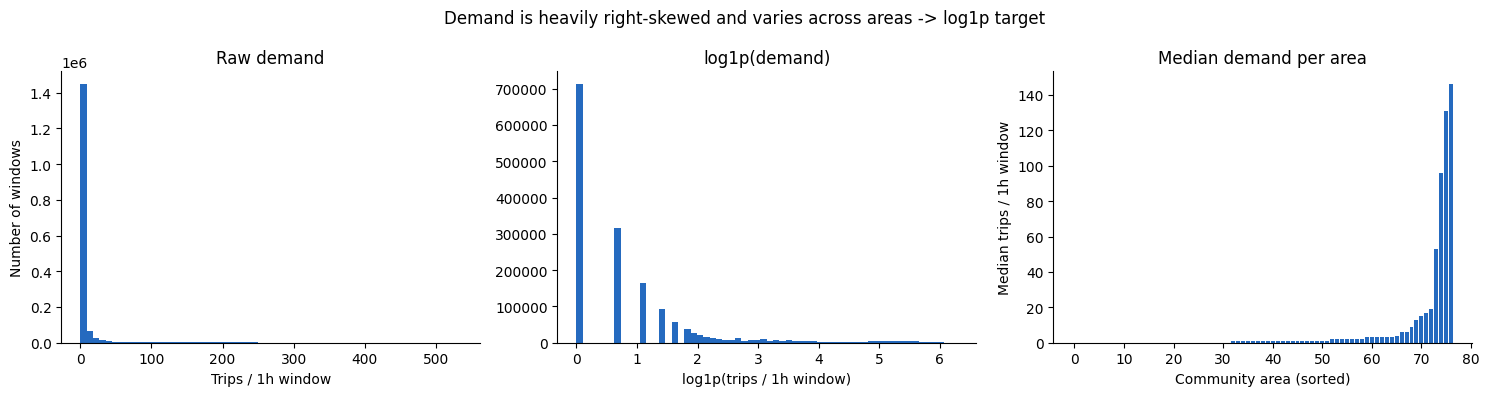

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(panel["count"], bins=60, color=SEQUENTIAL_BLUE)
axes[0].set_title("Raw demand")
axes[0].set_xlabel("Trips / 1h window")
axes[0].set_ylabel("Number of windows")

axes[1].hist(np.log1p(panel["count"]), bins=60, color=SEQUENTIAL_BLUE)
axes[1].set_title("log1p(demand)")
axes[1].set_xlabel("log1p(trips / 1h window)")

area_median_sorted = panel.groupby("community_area")["count"].median().sort_values()
axes[2].bar(range(len(area_median_sorted)), area_median_sorted.to_numpy(), color=SEQUENTIAL_BLUE, width=0.8)
axes[2].set_title("Median demand per area")
axes[2].set_xlabel("Community area (sorted)")
axes[2].set_ylabel("Median trips / 1h window")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("Demand is heavily right-skewed and varies across areas -> log1p target")
plt.tight_layout()
plt.show()

## 3. Feature Set & Shared Helpers

Same 17 features + 76 dummies as `03.03`; same evaluation helpers, copied verbatim.

In [5]:
FEATURE_COLS = [
    "temperature_2m", "precipitation", "snowfall", "wind_speed_10m", "cloud_cover",
    "hour_sin", "hour_cos", "hour_sin2", "hour_cos2",
    "day_of_week_sin", "day_of_week_cos", "day_of_week_sin2", "day_of_week_cos2",
    "month_sin", "month_cos", "is_weekend", "is_holiday",
]
ALL_COLS = FEATURE_COLS + DUMMY_COLS

preprocess = ColumnTransformer([
    ("scale", StandardScaler(), FEATURE_COLS),
    ("area_dummies", "passthrough", DUMMY_COLS),
])

train = panel[panel["timestamp"] < TRAIN_END].reset_index(drop=True)
test  = panel[panel["timestamp"] >= TRAIN_END].reset_index(drop=True)
y_true = test["count"].to_numpy(dtype=float)
print(f"train={len(train):,} rows   test={len(test):,} rows")


def metrics(y_true, y_pred):
    return {
        "r2":   round(r2_score(y_true, y_pred), 4),
        "mae":  round(mean_absolute_error(y_true, y_pred), 2),
        "rmse": round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 2),
    }


UNIT_WEIGHT = train.groupby("community_area")["count"].mean()
TEST_UNIT_WEIGHTS = test["community_area"].map(UNIT_WEIGHT).fillna(UNIT_WEIGHT.mean()).to_numpy()


def weighted_rmse(y_true, y_pred, weights):
    return float(np.sqrt(np.average((np.asarray(y_true) - np.asarray(y_pred)) ** 2, weights=weights)))


def predict_counts(model, X):
    y_log = np.clip(model.predict(X), -LOG_PRED_CAP, LOG_PRED_CAP)
    return np.clip(np.expm1(y_log), 0, None)


def per_area_results(test_df, y_pred, group_col="community_area"):
    tmp = pd.DataFrame({
        group_col: test_df[group_col].to_numpy(),
        "y_true": test_df["count"].to_numpy(dtype=float),
        "y_pred": y_pred,
    })
    rows = [
        {group_col: g, **metrics(g_df["y_true"], g_df["y_pred"])}
        for g, g_df in tmp.groupby(group_col)
    ]
    return pd.DataFrame(rows)


def skill_vs_baseline(results_df, baseline_df=None, group_col="community_area"):
    if baseline_df is None:
        baseline_df = baseline_results
    base = baseline_df[[group_col, "mae"]].rename(columns={"mae": "mae_base"})
    merged = results_df.merge(base, on=group_col)
    return (1 - merged["mae"] / merged["mae_base"]).rename("skill")


AREA_MEDIAN_DEMAND = panel.groupby("community_area")["count"].median().rename("median_demand")


def weighted_skill_vs_baseline(results_df, baseline_df=None, median_demand=None, group_col="community_area"):
    if median_demand is None:
        median_demand = AREA_MEDIAN_DEMAND
    skill = skill_vs_baseline(results_df, baseline_df=baseline_df, group_col=group_col)
    weights = results_df[[group_col]].merge(
        median_demand, left_on=group_col, right_index=True
    )["median_demand"].to_numpy()
    return float(np.average(skill.to_numpy(), weights=weights))


def relative_mae(results_df, median_demand=None, group_col="community_area"):
    if median_demand is None:
        median_demand = AREA_MEDIAN_DEMAND
    demand = results_df[[group_col]].merge(
        median_demand, left_on=group_col, right_index=True
    )["median_demand"].to_numpy()
    return pd.Series(results_df["mae"].to_numpy() / (demand + 1), index=results_df.index, name="relative_mae")


def print_pooled_results(label, pooled_metrics, per_area_df, baseline_df=None, median_demand=None,
                          group_col="community_area", weighted_rmse_value=None):
    w_skill = weighted_skill_vs_baseline(
        per_area_df, baseline_df=baseline_df, median_demand=median_demand, group_col=group_col,
    )
    print(label)
    print(f"  Pooled       : R2={pooled_metrics['r2']:.3f}  MAE={pooled_metrics['mae']:.2f}  "
          f"RMSE={pooled_metrics['rmse']:.2f}  (sanity check only)")
    if weighted_rmse_value is not None:
        print(f"  Weighted RMSE: {weighted_rmse_value:.2f}  (headline)")
    print(f"  Skill        : demand-weighted (headline)={w_skill:+.3f}  "
          f"unweighted median={per_area_df['skill'].median():+.3f}  "
          f"median R2={per_area_df['r2'].median():.3f}  "
          f"(areas with negative skill: {(per_area_df['skill']<0).sum()} of {len(per_area_df)})")

train=1,350,888 rows   test=279,048 rows


### 3.1 Feature Correlations

Re-run rather than assumed: hour sin/cos now spans 24 values instead of 6 -- confirms
orthogonality still holds exactly.

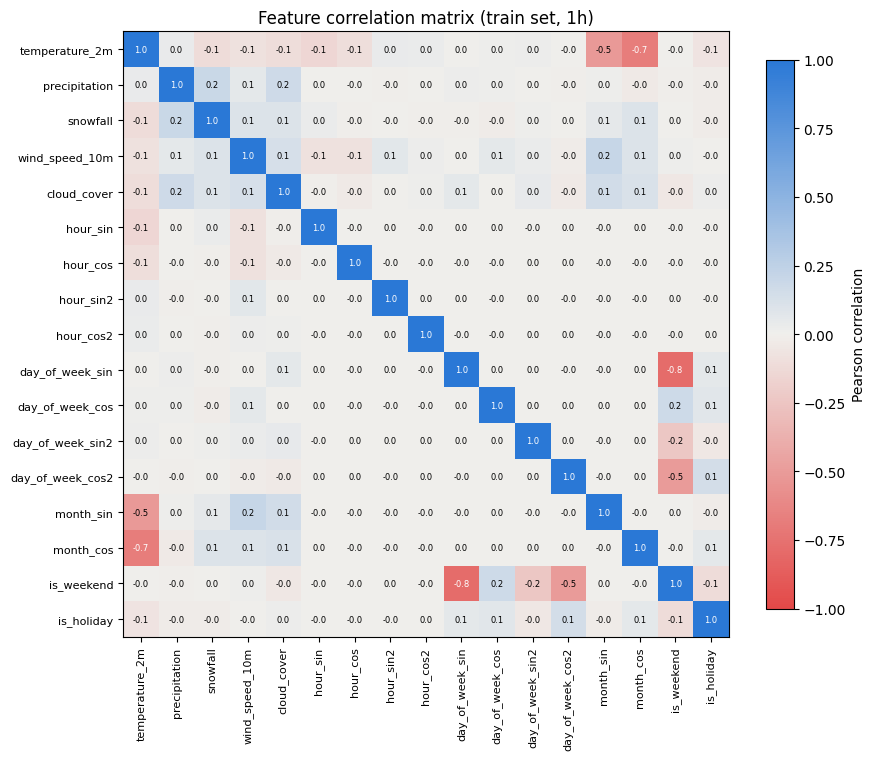

In [6]:
corr = train[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap=DIVERGING_CMAP, vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_COLS)))
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_xticklabels(FEATURE_COLS, rotation=90, fontsize=8)
ax.set_yticklabels(FEATURE_COLS, fontsize=8)
for i in range(len(FEATURE_COLS)):
    for j in range(len(FEATURE_COLS)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=6,
                color="white" if abs(val) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson correlation")
ax.set_title("Feature correlation matrix (train set, 1h)")
plt.tight_layout()
plt.show()

## 4. Profile Baseline

24 hourly buckets instead of 4h's 6 -- captures within-day patterns (e.g. exact rush-hour peak)
the 4h baseline blurs together. Expect a stronger reference here, not weaker.

Profile baseline, all 77 areas (2s)
  Pooled  : R2=0.918  MAE=2.86  RMSE=10.64  Weighted RMSE=39.46
  Per area: median R2=0.028  median MAE=0.86  median RMSE=1.12  (areas with R2<0: 36 of 77)


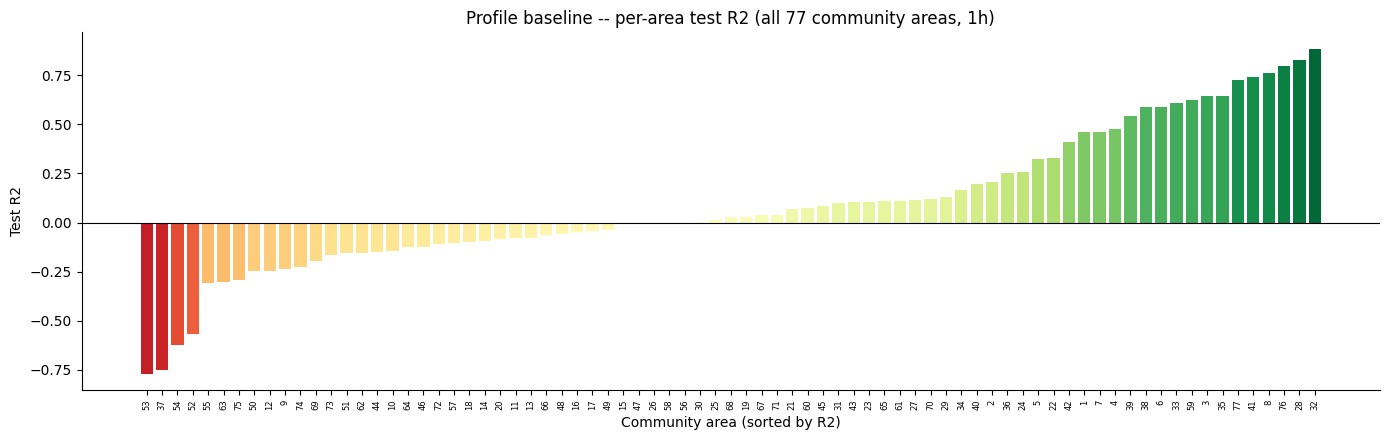

In [7]:
def profile_baseline(panel, groups, group_col="community_area"):
    results = []
    y_true_all, y_pred_all = [], []
    for g in groups:
        df_g = panel[panel[group_col] == g]
        tr = df_g[df_g["timestamp"] < TRAIN_END]
        te = df_g[df_g["timestamp"] >= TRAIN_END]
        profile = tr.groupby(["hour", "day_of_week", "month"])["count"].mean()
        fallback = tr["count"].mean()
        keys = pd.MultiIndex.from_arrays([te["hour"], te["day_of_week"], te["month"]])
        y_pred = profile.reindex(keys).fillna(fallback).to_numpy()
        y_true_ = te["count"].to_numpy(dtype=float)
        results.append({
            group_col: g,
            "median_demand": float(df_g["count"].median()),
            **metrics(y_true_, y_pred),
        })
        y_true_all.append(y_true_)
        y_pred_all.append(y_pred)
    per_group_df = pd.DataFrame(results)
    y_true_concat, y_pred_concat = np.concatenate(y_true_all), np.concatenate(y_pred_all)
    pooled = metrics(y_true_concat, y_pred_concat)
    return per_group_df, pooled, y_true_concat, y_pred_concat


t0 = time.time()
baseline_results, pm_baseline, baseline_y_true, baseline_y_pred = profile_baseline(panel, ALL_AREAS)
baseline_results["community_area"] = baseline_results["community_area"].astype(int)
baseline_results["relative_mae"] = baseline_results["mae"] / (baseline_results["median_demand"] + 1)
fit_time_base = time.time() - t0

print(f"Profile baseline, all 77 areas ({fit_time_base:.0f}s)")
print(f"  Pooled  : R2={pm_baseline['r2']:.3f}  MAE={pm_baseline['mae']:.2f}  RMSE={pm_baseline['rmse']:.2f}  "
      f"Weighted RMSE={weighted_rmse(y_true, baseline_y_pred, TEST_UNIT_WEIGHTS):.2f}")
print(f"  Per area: median R2={baseline_results['r2'].median():.3f}  "
      f"median MAE={baseline_results['mae'].median():.2f}  "
      f"median RMSE={baseline_results['rmse'].median():.2f}  "
      f"(areas with R2<0: {(baseline_results['r2']<0).sum()} of {len(baseline_results)})")

plot_df = baseline_results.sort_values("r2").reset_index(drop=True)
vlim = max(0.5, plot_df["r2"].abs().max())
colors = plt.cm.RdYlGn((plot_df["r2"] + vlim) / (2 * vlim))

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.bar(range(len(plot_df)), plot_df["r2"], color=colors, width=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df["community_area"], rotation=90, fontsize=6)
ax.set_xlabel("Community area (sorted by R2)")
ax.set_ylabel("Test R2")
ax.set_title("Profile baseline -- per-area test R2 (all 77 community areas, 1h)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 4.1 Baseline Performance

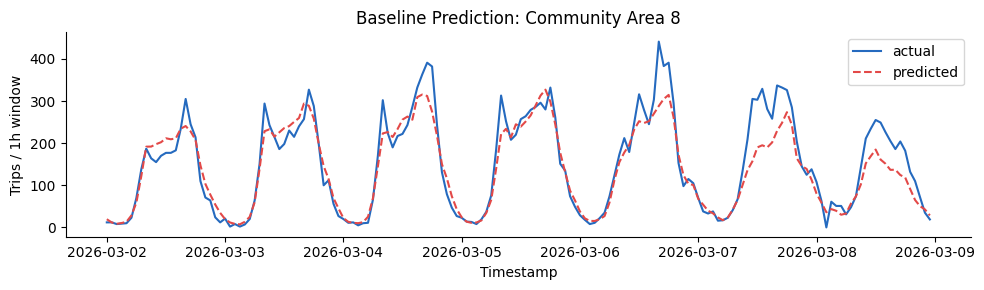

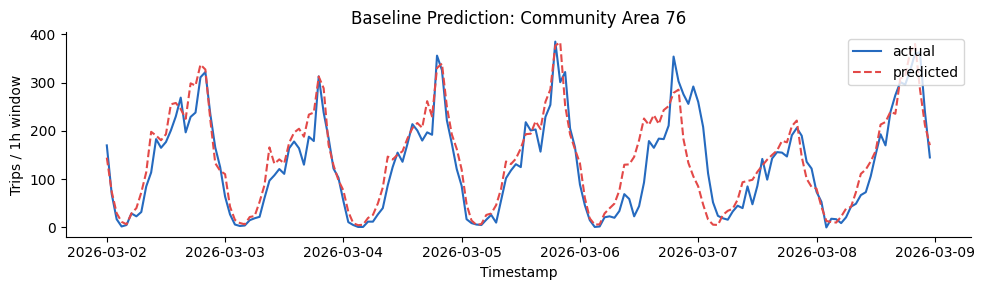

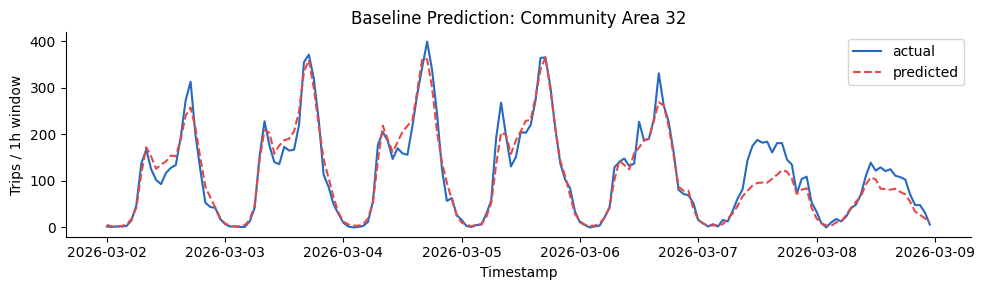

In [8]:
eval_mask = (test["timestamp"] >= EVAL_WEEK_START) & (test["timestamp"] < EVAL_WEEK_END)
test_plot = test[eval_mask].reset_index(drop=True)
test_plot_pred_base = baseline_y_pred[eval_mask.to_numpy()]

top_3_areas = test_plot.groupby("community_area")["count"].median().sort_values(ascending=False).head(3).index

for area in top_3_areas:
    mask = (test_plot["community_area"] == area).to_numpy()
    area_val = test_plot[mask]
    area_pred = test_plot_pred_base[mask]

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(area_val["timestamp"], area_val["count"], label="actual", color=SEQUENTIAL_BLUE)
    ax.plot(area_val["timestamp"], area_pred, label="predicted", color="#e34948", linestyle="--")
    ax.set_title(f"Baseline Prediction: Community Area {area}")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Trips / 1h window")
    ax.legend(loc="upper right")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

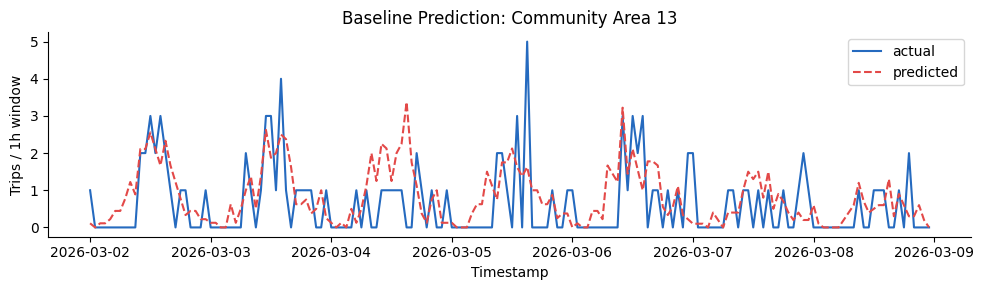

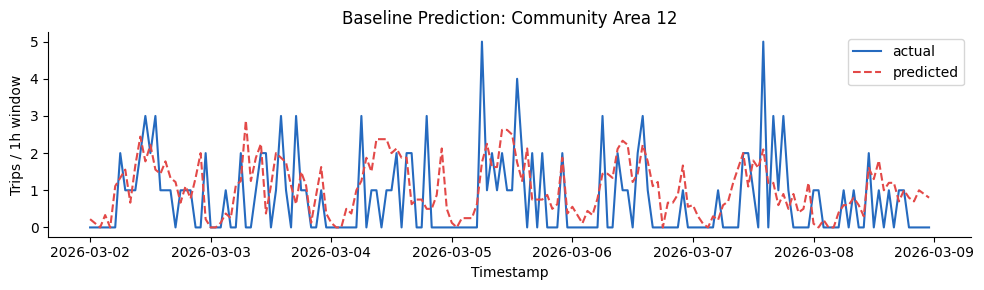

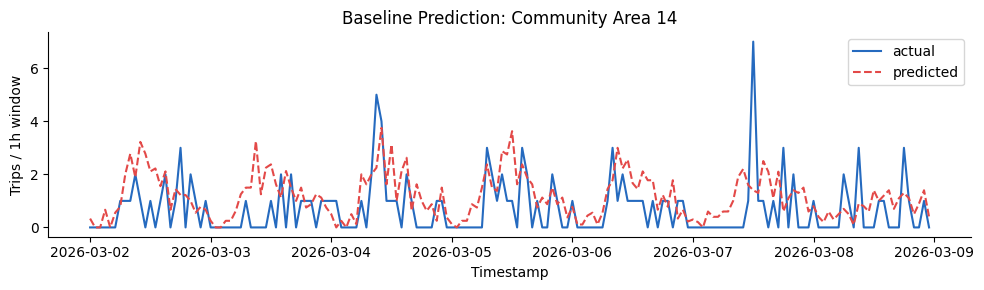

In [9]:
bottom_3_areas = test_plot.groupby("community_area")["count"].median().sort_values(ascending=True).head(3).index

for area in bottom_3_areas:
    mask = (test_plot["community_area"] == area).to_numpy()
    area_val = test_plot[mask]
    area_pred = test_plot_pred_base[mask]

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(area_val["timestamp"], area_val["count"], label="actual", color=SEQUENTIAL_BLUE)
    ax.plot(area_val["timestamp"], area_pred, label="predicted", color="#e34948", linestyle="--")
    ax.set_title(f"Baseline Prediction: Community Area {area}")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Trips / 1h window")
    ax.legend(loc="upper right")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

## 5. Shallow Neural Network -- Pooled, No Tuning

Same architecture as `03.03` (`ShallowNet`, `hidden_dim=64`), fit on ~4x the rows -- isolates the
effect of resolution, not tuning. Same corrected training machinery as `03.03`: day-blocked
`nn_fit`/`nn_es` split, early stopping on **count-space demand-weighted RMSE**, and a
**full-train refit** of the reported model. Unlike liblinear's near-linear scaling (`03.02`'s
framing), mini-batch SGD training cost scales with the number of batches, i.e. also close to
linearly in rows -- so expect roughly ~4x `03.03`'s fit time, not more.


In [10]:
# Day-blocked early-stopping split (see Validation Strategy). At any given timestamp the 77
# community areas share the same weather/time features and differ only by their (static) area
# dummy, so a row-random split can place near-identical rows on both sides. Splitting whole
# DAYS keeps every window on one side -- the same fix 03.05 uses at tract level (and the reason
# the earlier random-split version of this notebook was inconsistent with it).
train_days = np.sort(train["timestamp"].dt.normalize().unique())
rng_split = np.random.default_rng(SEED)
n_es_days = int(round(0.2 * len(train_days)))
es_days = {pd.Timestamp(d) for d in rng_split.choice(train_days, size=n_es_days, replace=False)}
es_mask = train["timestamp"].dt.normalize().isin(es_days)

nn_fit = train[~es_mask].reset_index(drop=True)
nn_es  = train[es_mask].reset_index(drop=True)
print(f"nn_fit: {len(nn_fit):,} rows ({len(train_days) - n_es_days} train days)")
print(f"nn_es:  {len(nn_es):,} rows ({n_es_days} held-out days -- no timestamp shared with nn_fit)")

# Demand weights for the (day-blocked) ES slice -- the SAME weighting the headline weighted RMSE
# uses, so early stopping optimizes the reported count-space metric rather than log-space MSE.
es_unit_w = nn_es["community_area"].map(UNIT_WEIGHT).fillna(UNIT_WEIGHT.mean()).to_numpy()
es_true   = nn_es["count"].to_numpy(dtype=float)


def make_xy(df, cols, preprocess_obj, fit=False):
    """DataFrame -> (X, y) torch tensors with log1p-transformed y. `fit=True` fits
    `preprocess_obj` on this frame (only ever training splits, never nn_es/test)."""
    Xs = (preprocess_obj.fit_transform(df[cols]) if fit else preprocess_obj.transform(df[cols])).astype(np.float32)
    y = np.log1p(df["count"].to_numpy(dtype=np.float32))
    return torch.from_numpy(Xs), torch.from_numpy(y)


class TorchRegressor:
    """Wraps a trained torch model + its fitted ColumnTransformer behind a sklearn-style
    .predict(X), so predict_counts / the Section 3 evaluation helpers work unchanged."""
    def __init__(self, model, preprocess_obj):
        self.model, self.preprocess_obj = model, preprocess_obj

    def predict(self, X):
        Xs = self.preprocess_obj.transform(X).astype(np.float32)
        self.model.eval()
        with torch.no_grad():
            return self.model(torch.from_numpy(Xs).to(device)).cpu().numpy()


class ShallowNet(nn.Module):
    """One hidden layer + ReLU -- Section 5's model."""
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x))).squeeze(-1)


class DeepNet(nn.Module):
    """Two hidden layers + dropout (L2 via the optimizer's weight_decay) -- Section 6's model family."""
    def __init__(self, input_dim, hidden_dim1=128, hidden_dim2=64, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        self.fc3 = nn.Linear(hidden_dim2, 1)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        return self.fc3(x).squeeze(-1)


class DeepNet5(nn.Module):
    """Five hidden layers + dropout after each -- Section 6's largest architecture candidate."""
    def __init__(self, input_dim, hidden_dims=(512, 256, 128, 64, 32), dropout=0.2):
        super().__init__()
        dims = [input_dim] + list(hidden_dims)
        self.layers = nn.ModuleList([nn.Linear(dims[i], dims[i + 1]) for i in range(len(dims) - 1)])
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_dims[-1], 1)

    def forward(self, x):
        for layer in self.layers:
            x = self.drop(self.relu(layer(x)))
        return self.out(x).squeeze(-1)


def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * len(xb)
    return running / len(loader.dataset)


def eval_loss(model, X, y, criterion):
    model.eval()
    with torch.no_grad():
        return criterion(model(X.to(device)), y.to(device)).item()


def fit_with_early_stopping(model_ctor, X_fit_t, y_fit_t, X_es_t, y_es_t, lr, weight_decay, batch_size,
                             nn_es_df, preprocess_obj, unit_weights, es_true_counts, all_cols,
                             max_epochs=NN_MAX_EPOCHS, patience=NN_PATIENCE, label=""):
    """Stop on count-space demand-weighted RMSE on the (day-blocked) ES slice, not log-space
    MSE -- the same metric the headline weighted RMSE / skill use, and the same corrected
    procedure as 03.05. Used only to FIND the stopping epoch; the reported model is refit on
    full train via fit_fixed_epochs so the NN entry isn't handicapped by the 80% fit split
    (03.01's SVM fits on full train)."""
    torch.manual_seed(SEED)
    model = model_ctor().to(device)
    criterion = nn.MSELoss()  # still the training loss; just not the stopping signal
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loader = DataLoader(TensorDataset(X_fit_t, y_fit_t), batch_size=batch_size, shuffle=True,
                         generator=torch.Generator().manual_seed(SEED))

    best_loss, best_epoch, best_state, no_improve = float("inf"), 0, None, 0
    epoch = 0
    for epoch in range(1, max_epochs + 1):
        train_epoch(model, loader, criterion, optimizer)
        es_pred = predict_counts(TorchRegressor(model, preprocess_obj), nn_es_df[all_cols])
        es_loss = weighted_rmse(es_true_counts, es_pred, unit_weights)
        if es_loss < best_loss - 1e-5:
            best_loss, best_epoch, no_improve = es_loss, epoch, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                break
    model.load_state_dict(best_state)
    print(f"{label}: stopped after {epoch} epochs (best epoch {best_epoch}, early-stop wRMSE {best_loss:.4f})")
    return model, best_epoch, best_loss


def fit_fixed_epochs(model_ctor, X_t, y_t, lr, weight_decay, batch_size, n_epochs, label=""):
    """Refit from scratch on ALL of train for n_epochs (the epoch count early stopping selected),
    no held-out slice -- so the final NN entry uses the full training set, matching 03.01's SVM."""
    torch.manual_seed(SEED)
    model = model_ctor().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True,
                         generator=torch.Generator().manual_seed(SEED))
    n = max(1, int(n_epochs))
    for _ in range(n):
        train_epoch(model, loader, criterion, optimizer)
    print(f"{label}: refit on full train for {n} epochs")
    return model


nn_fit: 1,081,080 rows (585 train days)
nn_es:  269,808 rows (146 held-out days -- no timestamp shared with nn_fit)


In [11]:
t0 = time.time()
# --- ES phase: scaler fit on nn_fit, find best_epoch on the day-blocked nn_es slice ---
prep_shallow_es = ColumnTransformer([
    ("scale", StandardScaler(), FEATURE_COLS),
    ("area_dummies", "passthrough", DUMMY_COLS),
])
X_fit_t, y_fit_t = make_xy(nn_fit, ALL_COLS, prep_shallow_es, fit=True)
X_es_t,  y_es_t  = make_xy(nn_es,  ALL_COLS, prep_shallow_es, fit=False)

shallow_ctor = lambda: ShallowNet(len(ALL_COLS), hidden_dim=64)
shallow_model_es, shallow_best_epoch, shallow_es_loss = fit_with_early_stopping(
    shallow_ctor, X_fit_t, y_fit_t, X_es_t, y_es_t, lr=1e-3, weight_decay=0.0, batch_size=512,
    nn_es_df=nn_es, preprocess_obj=prep_shallow_es, unit_weights=es_unit_w,
    es_true_counts=es_true, all_cols=ALL_COLS, label="Shallow NN (ES phase)",
)
# nn_fit-only model + its scaler -- kept for permutation importance (nn_es stays out-of-sample).
shallow_wrapper_es = TorchRegressor(shallow_model_es, prep_shallow_es)

# --- Final model: refit from scratch on ALL of train for best_epoch epochs, fresh scaler ---
prep_shallow = ColumnTransformer([
    ("scale", StandardScaler(), FEATURE_COLS),
    ("area_dummies", "passthrough", DUMMY_COLS),
])
X_train_s, y_train_s = make_xy(train, ALL_COLS, prep_shallow, fit=True)
shallow_model = fit_fixed_epochs(shallow_ctor, X_train_s, y_train_s, lr=1e-3, weight_decay=0.0,
                                 batch_size=512, n_epochs=shallow_best_epoch, label="Shallow NN (full-train refit)")
shallow_wrapper = TorchRegressor(shallow_model, prep_shallow)

y_pred_shallow = predict_counts(shallow_wrapper, test[ALL_COLS])
pm_shallow = metrics(y_true, y_pred_shallow)
res_shallow = per_area_results(test, y_pred_shallow)
res_shallow["skill"] = skill_vs_baseline(res_shallow)
res_shallow["relative_mae"] = relative_mae(res_shallow)
fit_time_shallow = time.time() - t0

print_pooled_results(f"Shallow NN ({fit_time_shallow:.0f}s)", pm_shallow, res_shallow,
                     weighted_rmse_value=weighted_rmse(y_true, y_pred_shallow, TEST_UNIT_WEIGHTS))


Shallow NN (ES phase): stopped after 17 epochs (best epoch 9, early-stop wRMSE 34.8244)
Shallow NN (full-train refit): refit on full train for 9 epochs
Shallow NN (380s)
  Pooled       : R2=0.903  MAE=2.93  RMSE=11.57  (sanity check only)
  Weighted RMSE: 42.28  (headline)
  Skill        : demand-weighted (headline)=-0.048  unweighted median=+0.118  median R2=0.196  (areas with negative skill: 12 of 77)


### 5.1 Feature Importance (Permutation Importance)

Worth comparing against `03.03`'s chart: does finer resolution shift importance toward the hour
harmonics, relative to weather? Same method as `03.03` (shuffle one feature at a time, measure
the increase in weighted RMSE on `nn_es`).

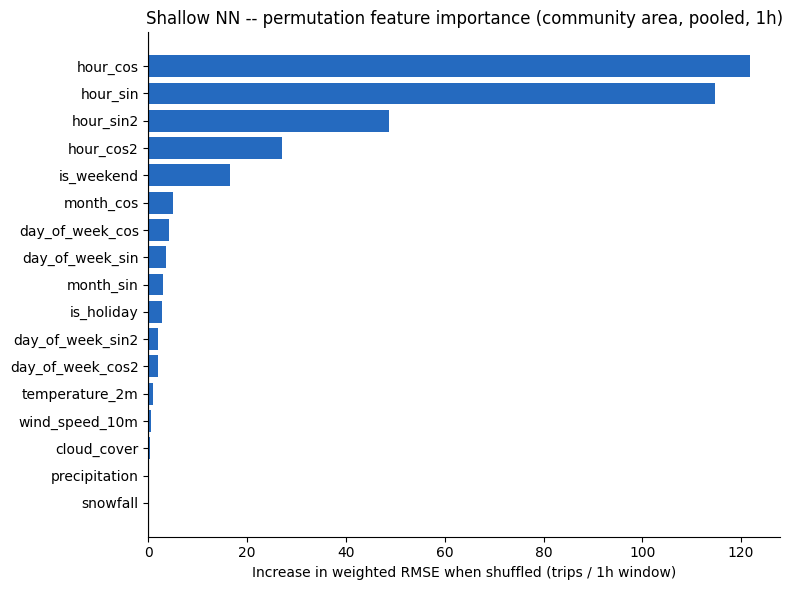

In [12]:
def permutation_importance_nn(model_wrapper, df, cols, n=17, n_repeats=3, seed=SEED):
    """Increase in weighted RMSE when a feature's values are shuffled (averaged over n_repeats)."""
    rng = np.random.default_rng(seed)
    base_pred = predict_counts(model_wrapper, df[cols])
    unit_w = df["community_area"].map(UNIT_WEIGHT).fillna(UNIT_WEIGHT.mean()).to_numpy()
    base_score = weighted_rmse(df["count"].to_numpy(dtype=float), base_pred, unit_w)

    rows = []
    for col in cols:
        if col in DUMMY_COLS:
            continue
        deltas = []
        for _ in range(n_repeats):
            df_shuf = df.copy()
            df_shuf[col] = rng.permutation(df_shuf[col].to_numpy())
            pred = predict_counts(model_wrapper, df_shuf[cols])
            deltas.append(weighted_rmse(df_shuf["count"].to_numpy(dtype=float), pred, unit_w) - base_score)
        rows.append({"feature": col, "importance": float(np.mean(deltas))})

    return pd.DataFrame(rows).sort_values("importance", ascending=False).head(n)


# nn_fit-only model on the out-of-sample nn_es slice -> honest permutation importances.
top_imp_shallow = permutation_importance_nn(shallow_wrapper_es, nn_es, ALL_COLS)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_imp_shallow["feature"][::-1], top_imp_shallow["importance"][::-1], color=SEQUENTIAL_BLUE)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(f"Increase in weighted RMSE when shuffled (trips / {FREQ} window)")
ax.set_title(f"Shallow NN -- permutation feature importance (community area, pooled, {FREQ})")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## 6. Hyperparameter Tuning -- Reusing `03.03`'s Selected Architecture

No architecture search is repeated here. `03.03` runs the full one-factor-at-a-time screen +
combine-winners step once and exports the winning config to `results/best_deep_config.json`; this
notebook loads that config (with a fallback to `03.03`'s known winner if the file is absent) and
trains just that one Deep NN, using the same corrected procedure as Section 5 -- day-blocked ES
split, early stopping on count-space demand-weighted RMSE, and a full-train refit. Only the
*architecture* is reused; the stopping epoch is re-found on the 1h data, since the right epoch
count depends on the number of rows. Mini-batch training cost scales roughly linearly in rows, so
no subsampling is needed (unlike `03.02`'s kernel-SVR search).


In [13]:
# Reuse the architecture 03.03 selected (task: run the full grid search ONCE, in the 4h notebook,
# and reuse the winner here) rather than repeating it at 1h -- the tuning surface is the same, so
# re-searching would only add runtime. Load 03.03's exported config; fall back to its known winner
# (largest, least-regularized deep2) if the file isn't present yet, matching 03.05's convention.
CONFIG_PATH = pathlib.Path("../../results/best_deep_config.json")
DEFAULT_DEEP_CONFIG = {"arch": "deep2", "hidden_dim1": 512, "hidden_dim2": 256, "dropout": 0.0, "weight_decay": 0.0, "lr": 1e-3, "batch_size": 512}
if CONFIG_PATH.exists():
    BEST_DEEP_CONFIG = json.loads(CONFIG_PATH.read_text())
    print(f"Loaded tuned deep config from {CONFIG_PATH} "
          f"(selected in {BEST_DEEP_CONFIG.get('source_notebook', '03.03')}, "
          f"knob '{BEST_DEEP_CONFIG.get('selected_knob', 'n/a')}')")
else:
    BEST_DEEP_CONFIG = DEFAULT_DEEP_CONFIG
    print(f"{CONFIG_PATH} not found -- run 03.03 first to regenerate it. "
          f"Falling back to 03.03's known winner: {DEFAULT_DEEP_CONFIG}")
print(f"Reusing deep config: {BEST_DEEP_CONFIG}")


def build_deep_ctor(cfg):
    if cfg.get("arch", "deep2") == "deep2":
        return lambda: DeepNet(len(ALL_COLS), hidden_dim1=cfg["hidden_dim1"],
                               hidden_dim2=cfg["hidden_dim2"], dropout=cfg.get("dropout", 0.0))
    return lambda: DeepNet5(len(ALL_COLS), hidden_dims=tuple(cfg["hidden_dims"]), dropout=cfg.get("dropout", 0.0))


t0 = time.time()
# --- ES phase: find the stopping epoch on the day-blocked nn_es slice (same procedure as 03.03,
# just for one reused config instead of a grid). best_epoch is re-found on the 1h data because
# the right epoch count depends on rows/resolution; only the architecture is reused. ---
deep_ctor = build_deep_ctor(BEST_DEEP_CONFIG)
prep_deep_es = ColumnTransformer([
    ("scale", StandardScaler(), FEATURE_COLS),
    ("area_dummies", "passthrough", DUMMY_COLS),
])
X_fit_deep, y_fit_deep = make_xy(nn_fit, ALL_COLS, prep_deep_es, fit=True)
X_es_deep,  y_es_deep  = make_xy(nn_es,  ALL_COLS, prep_deep_es, fit=False)
deep_model_es, deep_best_epoch, deep_es_loss = fit_with_early_stopping(
    deep_ctor, X_fit_deep, y_fit_deep, X_es_deep, y_es_deep,
    lr=BEST_DEEP_CONFIG["lr"], weight_decay=BEST_DEEP_CONFIG["weight_decay"],
    batch_size=BEST_DEEP_CONFIG.get("batch_size", 512),
    nn_es_df=nn_es, preprocess_obj=prep_deep_es, unit_weights=es_unit_w,
    es_true_counts=es_true, all_cols=ALL_COLS, label="Deep NN (reused 03.03 config, ES phase)",
)

# --- Final model: refit from scratch on ALL of train for best_epoch epochs, fresh scaler ---
prep_deep = ColumnTransformer([
    ("scale", StandardScaler(), FEATURE_COLS),
    ("area_dummies", "passthrough", DUMMY_COLS),
])
X_train_d, y_train_d = make_xy(train, ALL_COLS, prep_deep, fit=True)
deep_model = fit_fixed_epochs(deep_ctor, X_train_d, y_train_d, lr=BEST_DEEP_CONFIG["lr"],
                              weight_decay=BEST_DEEP_CONFIG["weight_decay"],
                              batch_size=BEST_DEEP_CONFIG.get("batch_size", 512),
                              n_epochs=deep_best_epoch, label="Deep NN (full-train refit)")
deep_wrapper = TorchRegressor(deep_model, prep_deep)
fit_time_deep = time.time() - t0


Loaded tuned deep config from ..\..\results\best_deep_config.json (selected in 03.03_prediction_nn_CA_4h.ipynb, knob 'weight_decay=1e-4')
Reusing deep config: {'arch': 'deep2', 'dropout': 0.0, 'weight_decay': 0.0001, 'lr': 0.001, 'batch_size': 512, 'hidden_dim1': 128, 'hidden_dim2': 64, 'selected_knob': 'weight_decay=1e-4', 'source_notebook': '03.03_prediction_nn_CA_4h.ipynb', 'selected_at': '2026-07-21T20:31:42'}
Deep NN (reused 03.03 config, ES phase): stopped after 22 epochs (best epoch 14, early-stop wRMSE 33.3982)
Deep NN (full-train refit): refit on full train for 14 epochs


In [14]:
y_pred_deep = predict_counts(deep_wrapper, test[ALL_COLS])
pm_deep = metrics(y_true, y_pred_deep)
res_deep = per_area_results(test, y_pred_deep)
res_deep["skill"] = skill_vs_baseline(res_deep)
res_deep["relative_mae"] = relative_mae(res_deep)

print_pooled_results(f"Deep NN, reused 03.03 config ({fit_time_deep:.0f}s)", pm_deep, res_deep,
                     weighted_rmse_value=weighted_rmse(y_true, y_pred_deep, TEST_UNIT_WEIGHTS))


Deep NN, reused 03.03 config (591s)
  Pooled       : R2=0.928  MAE=2.66  RMSE=9.98  (sanity check only)
  Weighted RMSE: 36.26  (headline)
  Skill        : demand-weighted (headline)=+0.062  unweighted median=+0.090  median R2=0.167  (areas with negative skill: 5 of 77)


## 7. Results -- Model Comparison

Three candidates: profile baseline, Shallow NN, Deep NN (tuned) -- same set as `03.03`. No
demand-tiered or per-area variants at this resolution, same decision `03.02` makes on the SVM
side (Section 9 shortfall notes why).

Two headline metrics: demand-weighted skill and weighted RMSE. Unweighted median skill
and relative MAE are supporting detail.
           Model  Demand-weighted skill  Median skill  Weighted RMSE  Median relative MAE  Pooled R2  Median R2/area
Profile baseline                  0.000         0.000         39.460                0.458      0.918           0.028
      Shallow NN                 -0.048         0.118         42.275                0.400      0.903           0.196
 Deep NN (tuned)                  0.062         0.090         36.260                0.405      0.928           0.167


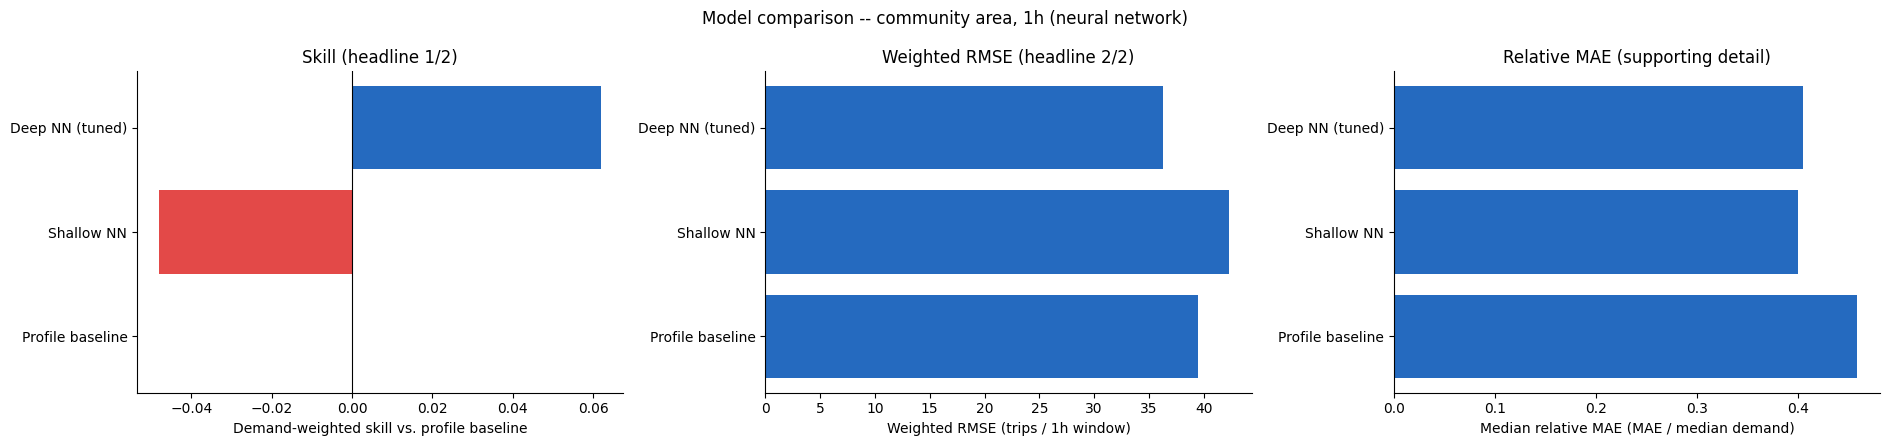

In [15]:
comparison_df = pd.DataFrame([
    {"Model": "Profile baseline", "Demand-weighted skill": 0.000, "Median skill": 0.000,
     "Weighted RMSE": weighted_rmse(y_true, baseline_y_pred, TEST_UNIT_WEIGHTS),
     "Median relative MAE": baseline_results["relative_mae"].median(),
     "Pooled R2": pm_baseline["r2"], "Median R2/area": baseline_results["r2"].median()},
    {"Model": "Shallow NN",
     "Demand-weighted skill": weighted_skill_vs_baseline(res_shallow), "Median skill": res_shallow["skill"].median(),
     "Weighted RMSE": weighted_rmse(y_true, y_pred_shallow, TEST_UNIT_WEIGHTS),
     "Median relative MAE": res_shallow["relative_mae"].median(),
     "Pooled R2": pm_shallow["r2"], "Median R2/area": res_shallow["r2"].median()},
    {"Model": "Deep NN (tuned)",
     "Demand-weighted skill": weighted_skill_vs_baseline(res_deep), "Median skill": res_deep["skill"].median(),
     "Weighted RMSE": weighted_rmse(y_true, y_pred_deep, TEST_UNIT_WEIGHTS),
     "Median relative MAE": res_deep["relative_mae"].median(),
     "Pooled R2": pm_deep["r2"], "Median R2/area": res_deep["r2"].median()},
]).round(3)
print("Two headline metrics: demand-weighted skill and weighted RMSE. Unweighted median skill")
print("and relative MAE are supporting detail.")
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(19, 4.5))
chart_df = comparison_df.set_index("Model")["Demand-weighted skill"]
colors_cmp = [SEQUENTIAL_BLUE if v >= 0 else "#e34948" for v in chart_df]
axes[0].barh(chart_df.index, chart_df.to_numpy(), color=colors_cmp)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Demand-weighted skill vs. profile baseline")
axes[0].set_title("Skill (headline 1/2)")
axes[0].spines[["top", "right"]].set_visible(False)

wrmse_df = comparison_df.set_index("Model")["Weighted RMSE"]
axes[1].barh(wrmse_df.index, wrmse_df.to_numpy(), color=SEQUENTIAL_BLUE)
axes[1].set_xlabel("Weighted RMSE (trips / 1h window)")
axes[1].set_title("Weighted RMSE (headline 2/2)")
axes[1].spines[["top", "right"]].set_visible(False)

rmae_df = comparison_df.set_index("Model")["Median relative MAE"]
axes[2].barh(rmae_df.index, rmae_df.to_numpy(), color=SEQUENTIAL_BLUE)
axes[2].set_xlabel("Median relative MAE (MAE / median demand)")
axes[2].set_title("Relative MAE (supporting detail)")
axes[2].spines[["top", "right"]].set_visible(False)
plt.suptitle("Model comparison -- community area, 1h (neural network)")
plt.tight_layout()
plt.show()

### 7.0b Are the Differences Real? Day-Block Bootstrap

The comparison table above reports one skill number per model, but the test period is a single
five-month window -- so how much of the Shallow-vs-Deep gap is signal? Same method as `03.05`'s
tract-level check: resample the test period by whole days with replacement (`N_BOOT` times,
preserving the within-day cross-area correlation) and recompute demand-weighted skill each time.
If the 95% CI for the Deep-minus-Shallow difference straddles zero, the two networks are
statistically indistinguishable here and the simpler one should be preferred.


Shallow NN   demand-weighted skill: -0.047  95% CI [-0.074, -0.020]
Deep NN      demand-weighted skill: +0.063  95% CI [+0.040, +0.085]

Deep - Shallow: +0.110  95% CI [+0.086, +0.132]  (P(Deep>Shallow)=1.00)
CI for the difference straddling 0 => the two NNs are statistically indistinguishable here.


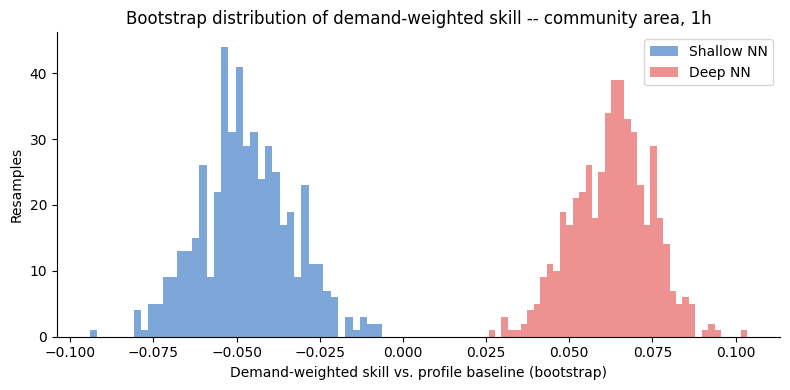

In [16]:
# Day-block bootstrap of demand-weighted skill (same method as 03.05's tract-level 5.7.0b):
# resample whole test days with replacement -- preserving the within-day cross-area correlation
# -- and recompute the headline metric each time, so the comparison table's skill gaps get a
# confidence interval instead of a single point estimate.
test_day  = test["timestamp"].dt.normalize().to_numpy()
uniq_days = np.unique(test_day)
area_arr  = test["community_area"].to_numpy()
count_arr = test["count"].to_numpy(dtype=float)
day_to_rows = {d: np.where(test_day == d)[0] for d in uniq_days}


def _weighted_skill_on_idx(idx, y_pred):
    a  = area_arr[idx]
    em = np.abs(count_arr[idx] - np.asarray(y_pred)[idx])
    eb = np.abs(count_arr[idx] - baseline_y_pred[idx])
    g  = pd.DataFrame({"a": a, "em": em, "eb": eb}).groupby("a").mean()
    g  = g[g["eb"] > 0]                       # skip areas with a degenerate (zero-MAE) baseline
    skill = 1 - g["em"] / g["eb"]
    w = AREA_MEDIAN_DEMAND.reindex(g.index).to_numpy()
    return float(np.average(skill.to_numpy(), weights=w)) if w.sum() > 0 else np.nan


def block_bootstrap(y_pred, n_boot=N_BOOT, seed=SEED):
    rng = np.random.default_rng(seed)
    out = np.empty(n_boot)
    for b in range(n_boot):
        days = rng.choice(uniq_days, size=len(uniq_days), replace=True)
        idx = np.concatenate([day_to_rows[d] for d in days])
        out[b] = _weighted_skill_on_idx(idx, y_pred)
    return out


boot_shallow = block_bootstrap(y_pred_shallow)
boot_deep    = block_bootstrap(y_pred_deep)
diff = boot_deep - boot_shallow


def _ci(a):
    a = a[~np.isnan(a)]
    return float(np.mean(a)), float(np.percentile(a, 2.5)), float(np.percentile(a, 97.5))


for name, b in [("Shallow NN", boot_shallow), ("Deep NN", boot_deep)]:
    m, lo, hi = _ci(b)
    print(f"{name:12s} demand-weighted skill: {m:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")
dm, dlo, dhi = _ci(diff)
p_better = float(np.mean(diff[~np.isnan(diff)] > 0))
print(f"\nDeep - Shallow: {dm:+.3f}  95% CI [{dlo:+.3f}, {dhi:+.3f}]  (P(Deep>Shallow)={p_better:.2f})")
print("CI for the difference straddling 0 => the two NNs are statistically indistinguishable here.")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_shallow, bins=40, alpha=0.6, color=SEQUENTIAL_BLUE, label="Shallow NN")
ax.hist(boot_deep,    bins=40, alpha=0.6, color="#e34948",       label="Deep NN")
ax.set_xlabel("Demand-weighted skill vs. profile baseline (bootstrap)")
ax.set_ylabel("Resamples")
ax.set_title(f"Bootstrap distribution of demand-weighted skill -- community area, {FREQ}")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### 7.0 Actual vs. Predicted (Test Set)

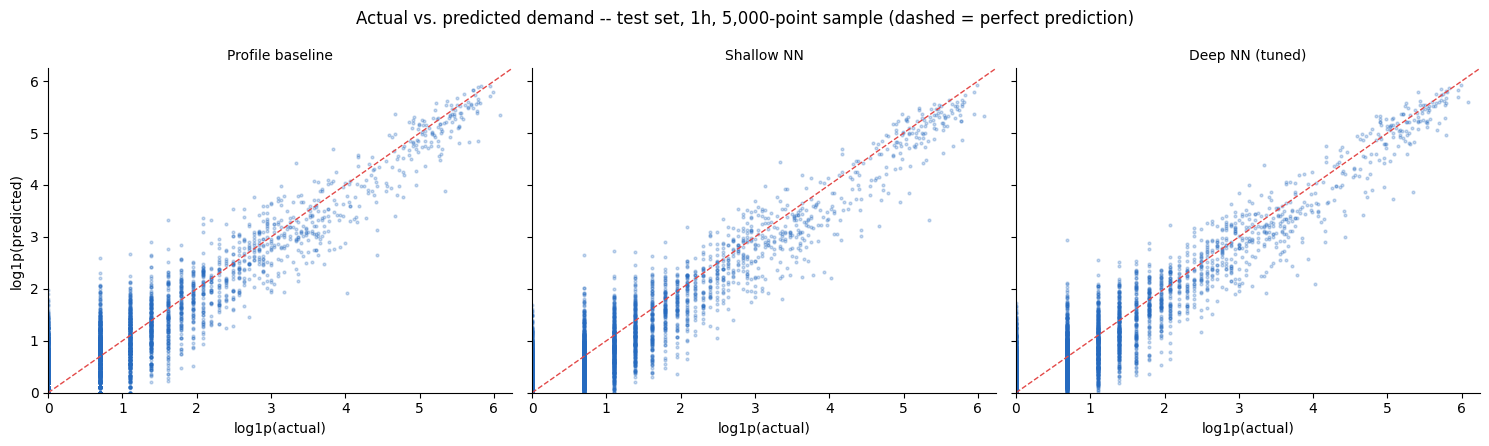

In [17]:
models_to_plot = [
    ("Profile baseline", baseline_y_pred),
    ("Shallow NN", y_pred_shallow),
    ("Deep NN (tuned)", y_pred_deep),
]

rng_viz = np.random.RandomState(0)
sample_n = min(5000, len(y_true))
sample_idx = rng_viz.choice(len(y_true), size=sample_n, replace=False)
log_true = np.log1p(y_true)
lims = [0, log_true.max()]

fig, axes = plt.subplots(1, len(models_to_plot), figsize=(15, 4.5), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, models_to_plot):
    log_pred = np.log1p(y_pred)
    ax.scatter(log_true[sample_idx], log_pred[sample_idx], s=4, alpha=0.25, color=SEQUENTIAL_BLUE)
    ax.plot(lims, lims, color="#e34948", linewidth=1, linestyle="--")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("log1p(actual)")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("log1p(predicted)")
plt.suptitle(f"Actual vs. predicted demand -- test set, 1h, {sample_n:,}-point sample "
             f"(dashed = perfect prediction)")
plt.tight_layout()
plt.show()

### 7.1 Per-Area Performance

NN entry carried forward for the per-area breakdown: Deep NN (tuned)


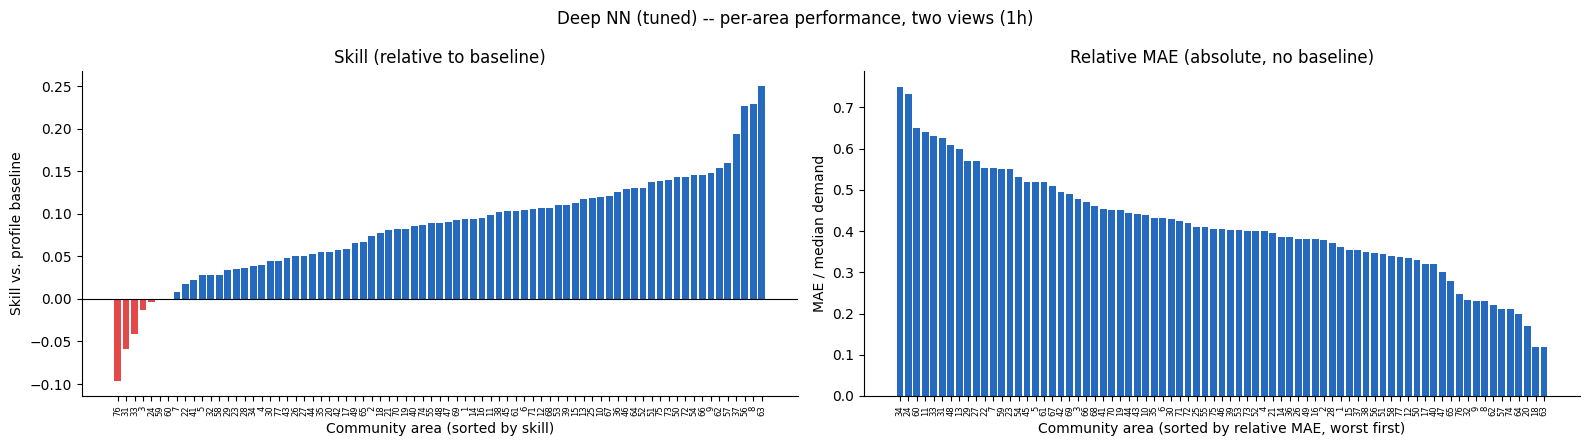

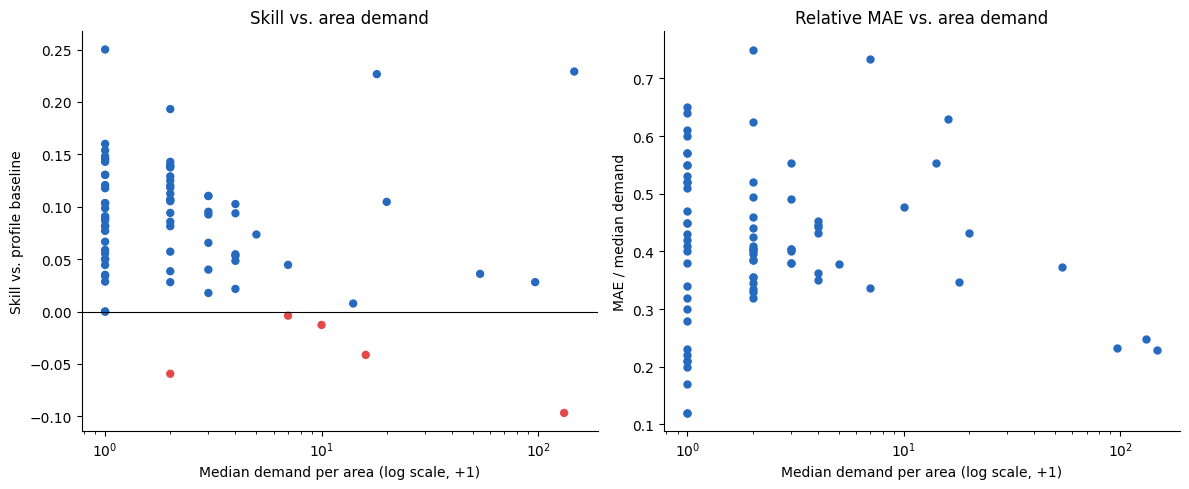

In [18]:
nn_entry_name = "Deep NN (tuned)" if weighted_skill_vs_baseline(res_deep) >= weighted_skill_vs_baseline(res_shallow) else "Shallow NN"
res_nn = res_deep if nn_entry_name == "Deep NN (tuned)" else res_shallow
y_pred_nn = y_pred_deep if nn_entry_name == "Deep NN (tuned)" else y_pred_shallow
print(f"NN entry carried forward for the per-area breakdown: {nn_entry_name}")

res_nn_by_skill = res_nn.merge(
    AREA_MEDIAN_DEMAND, left_on="community_area", right_index=True
).sort_values("skill").reset_index(drop=True)
colors_skill = [SEQUENTIAL_BLUE if v >= 0 else "#e34948" for v in res_nn_by_skill["skill"]]

res_nn_by_rmae = res_nn.merge(
    AREA_MEDIAN_DEMAND, left_on="community_area", right_index=True
).sort_values("relative_mae", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
axes[0].bar(range(len(res_nn_by_skill)), res_nn_by_skill["skill"], color=colors_skill, width=0.8)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xticks(range(len(res_nn_by_skill)))
axes[0].set_xticklabels(res_nn_by_skill["community_area"], rotation=90, fontsize=6)
axes[0].set_xlabel("Community area (sorted by skill)")
axes[0].set_ylabel("Skill vs. profile baseline")
axes[0].set_title("Skill (relative to baseline)")

axes[1].bar(range(len(res_nn_by_rmae)), res_nn_by_rmae["relative_mae"], color=SEQUENTIAL_BLUE, width=0.8)
axes[1].set_xticks(range(len(res_nn_by_rmae)))
axes[1].set_xticklabels(res_nn_by_rmae["community_area"], rotation=90, fontsize=6)
axes[1].set_xlabel("Community area (sorted by relative MAE, worst first)")
axes[1].set_ylabel("MAE / median demand")
axes[1].set_title("Relative MAE (absolute, no baseline)")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle(f"{nn_entry_name} -- per-area performance, two views (1h)")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(res_nn_by_skill["median_demand"] + 1, res_nn_by_skill["skill"], color=colors_skill, s=25)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xscale("log")
axes[0].set_xlabel("Median demand per area (log scale, +1)")
axes[0].set_ylabel("Skill vs. profile baseline")
axes[0].set_title("Skill vs. area demand")

axes[1].scatter(res_nn_by_rmae["median_demand"] + 1, res_nn_by_rmae["relative_mae"], color=SEQUENTIAL_BLUE, s=25)
axes[1].set_xscale("log")
axes[1].set_xlabel("Median demand per area (log scale, +1)")
axes[1].set_ylabel("MAE / median demand")
axes[1].set_title("Relative MAE vs. area demand")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Per-area skill map for the NN entry, full pooled data, 1h -- no areas excluded.

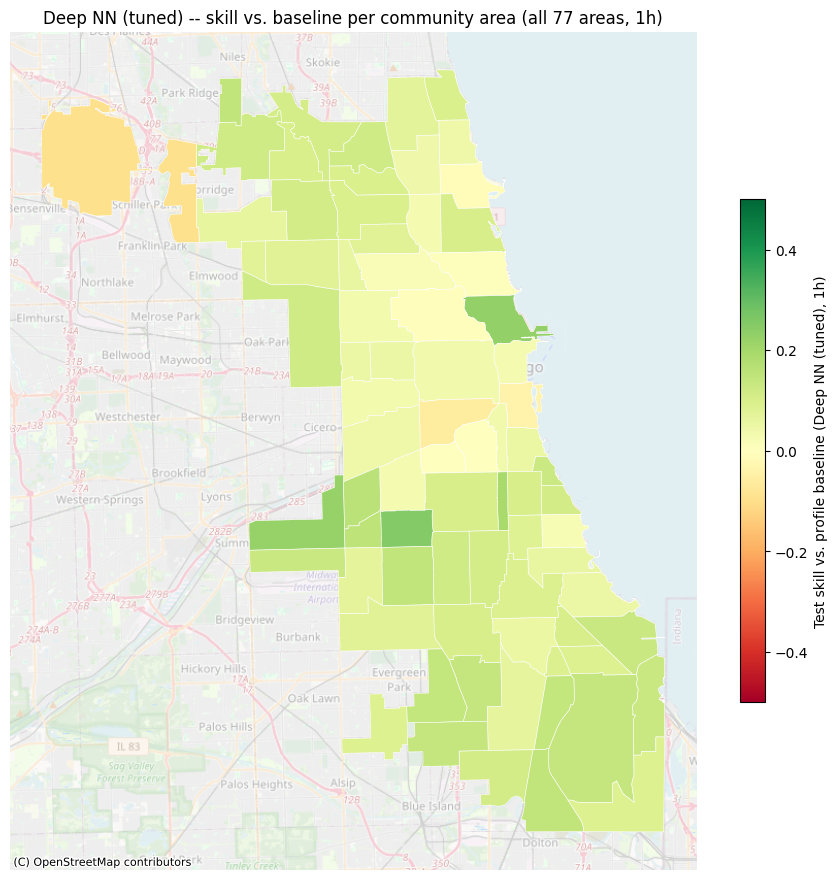

In [19]:
community_areas_gdf = gpd.read_file(COMMUNITY_AREAS_PATH)
community_areas_gdf["area_numbe"] = community_areas_gdf["area_numbe"].astype(int)

gdf_skill = community_areas_gdf.merge(
    res_nn[["community_area", "skill"]],
    left_on="area_numbe", right_on="community_area", how="left",
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(9, 9))
gdf_skill.plot(ax=ax, column="skill", cmap="RdYlGn", vmin=-0.5, vmax=0.5, legend=True,
               legend_kwds={"label": f"Test skill vs. profile baseline ({nn_entry_name}, 1h)", "shrink": 0.6},
               edgecolor="white", linewidth=0.4)
ctx.add_basemap(ax, crs=gdf_skill.crs, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.35)
ax.set_title(f"{nn_entry_name} -- skill vs. baseline per community area (all 77 areas, 1h)")
ax.axis("off")
plt.tight_layout()
plt.show()

### 7.2 Top 3 / Bottom 3 Areas -- All Models

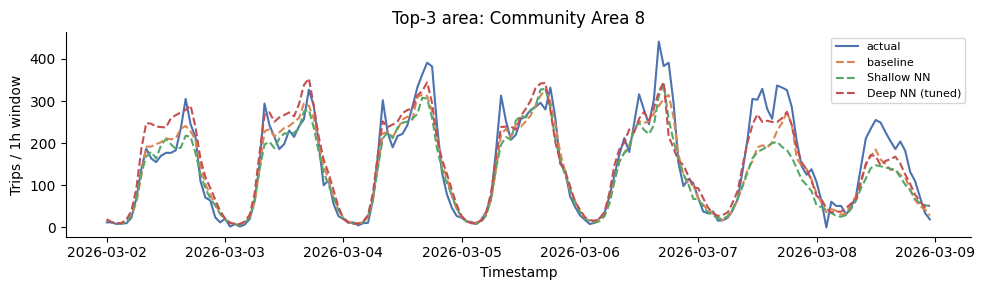

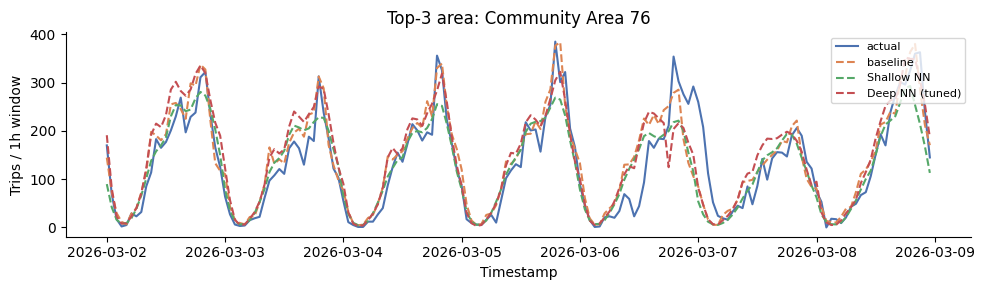

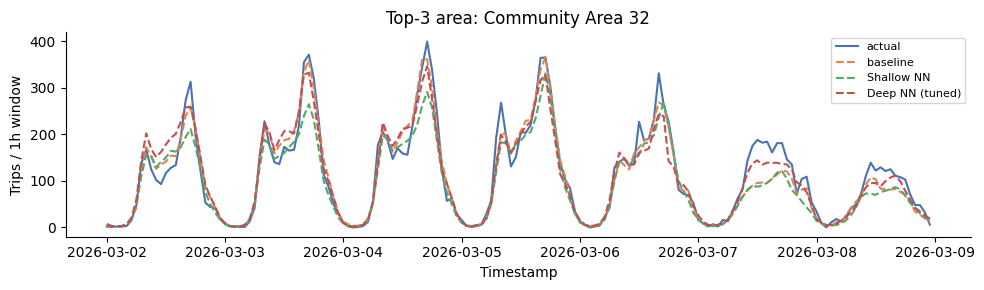

In [20]:
test_plot_pred_shallow = y_pred_shallow[eval_mask.to_numpy()]
test_plot_pred_deep    = y_pred_deep[eval_mask.to_numpy()]

models_to_plot_ts = [
    ("baseline", test_plot_pred_base),
    ("Shallow NN", test_plot_pred_shallow),
    ("Deep NN (tuned)", test_plot_pred_deep),
]


def plot_area_all_models(areas, title_prefix):
    for area in areas:
        mask = (test_plot["community_area"] == area).to_numpy()
        area_val = test_plot[mask]

        fig, ax = plt.subplots(figsize=(10, 3))
        ax.plot(area_val["timestamp"], area_val["count"], label="actual", color=CATEGORICAL_COLORS[0])
        for i, (name, y_pred) in enumerate(models_to_plot_ts):
            ax.plot(area_val["timestamp"], y_pred[mask], label=name,
                    color=CATEGORICAL_COLORS[i + 1], linestyle="--")
        ax.set_title(f"{title_prefix}: Community Area {area}")
        ax.set_xlabel("Timestamp")
        ax.set_ylabel("Trips / 1h window")
        ax.legend(loc="upper right", fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        plt.show()


plot_area_all_models(top_3_areas, "Top-3 area")

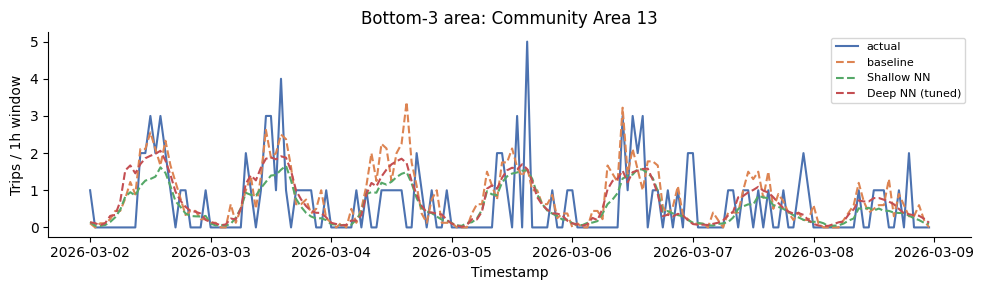

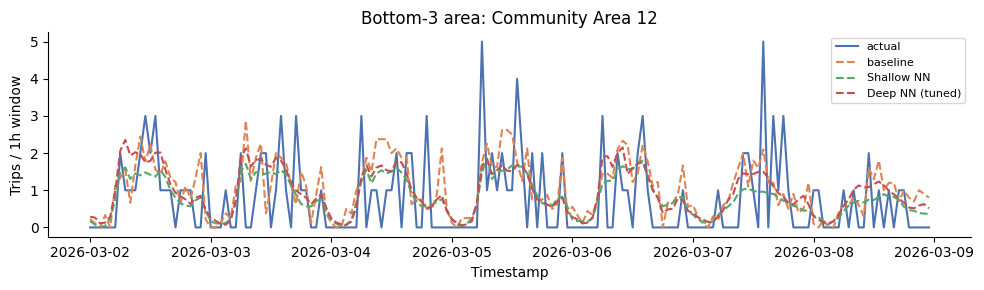

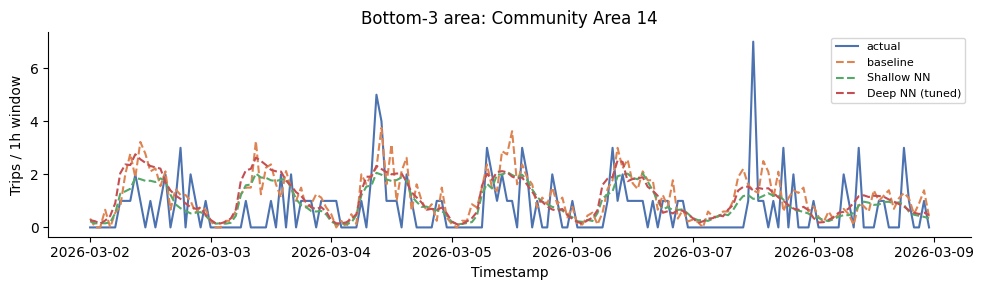

In [21]:
plot_area_all_models(bottom_3_areas, "Bottom-3 area")

## 8. Export Results

Append this run's three models to the shared results CSVs, same convention as `03.03`.

In [22]:
RESULTS_DIR = pathlib.Path("../../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_CSV = RESULTS_DIR / "model_results_summary.csv"
DETAIL_CSV  = RESULTS_DIR / "model_results_by_area.csv"
NOTEBOOK_NAME = "03.04_prediction_nn_CA_1h.ipynb"


def upsert_csv(df_new, path, key_cols):
    if path.exists():
        df_old = pd.read_csv(path)
        old_keys = df_old[key_cols].apply(tuple, axis=1)
        new_keys = set(df_new[key_cols].apply(tuple, axis=1))
        df_out = pd.concat([df_old[~old_keys.isin(new_keys)], df_new], ignore_index=True)
    else:
        df_out = df_new
    df_out.to_csv(path, index=False)
    return df_out


run_timestamp = pd.Timestamp.now().isoformat(timespec="seconds")

nn_models = [
    ("Profile baseline", pm_baseline, baseline_results, y_true, baseline_y_pred, TEST_UNIT_WEIGHTS,
     fit_time_base, 0.0, 0.0, len(ALL_AREAS)),
    ("Shallow NN", pm_shallow, res_shallow, y_true, y_pred_shallow, TEST_UNIT_WEIGHTS,
     fit_time_shallow, weighted_skill_vs_baseline(res_shallow), res_shallow["skill"].median(), len(ALL_AREAS)),
    ("Deep NN (tuned)", pm_deep, res_deep, y_true, y_pred_deep, TEST_UNIT_WEIGHTS,
     fit_time_deep, weighted_skill_vs_baseline(res_deep), res_deep["skill"].median(), len(ALL_AREAS)),
]

summary_rows, detail_rows = [], []
for model_name, pm, res_df, y_true_m, y_pred_m, weights_m, fit_time, skill_w, skill_med, n_units in nn_models:
    summary_rows.append({
        "model_name": model_name,
        "notebook": NOTEBOOK_NAME,
        "spatial_resolution": "community_area",
        "temporal_resolution": FREQ,
        "n_units": n_units,
        "train_start": DATA_START.date().isoformat(),
        "train_end": (TRAIN_END - pd.Timedelta(days=1)).date().isoformat(),
        "test_start": TRAIN_END.date().isoformat(),
        "test_end": (DATA_END_EXCL - pd.Timedelta(days=1)).date().isoformat(),
        "rmse": pm["rmse"],
        "mae": pm["mae"],
        "r2": pm["r2"],
        "weighted_rmse": weighted_rmse(y_true_m, y_pred_m, weights_m),
        "skill_demand_weighted": round(float(skill_w), 4),
        "skill_median": round(float(skill_med), 4),
        "fit_time_s": round(fit_time, 2),
        "last_run_at": run_timestamp,
    })
    for _, row in res_df.iterrows():
        detail_rows.append({
            "model_name": model_name,
            "notebook": NOTEBOOK_NAME,
            "spatial_resolution": "community_area",
            "temporal_resolution": FREQ,
            "unit_id": int(row["community_area"]),
            "median_demand": AREA_MEDIAN_DEMAND.get(row["community_area"]),
            "rmse": row["rmse"],
            "mae": row["mae"],
            "r2": row["r2"],
            "skill": row.get("skill", 0.0),
            "relative_mae": row["relative_mae"],
            "last_run_at": run_timestamp,
        })

summary_df = pd.DataFrame(summary_rows)
detail_df = pd.DataFrame(detail_rows)

upsert_csv(summary_df, SUMMARY_CSV,
           key_cols=["model_name", "notebook", "spatial_resolution", "temporal_resolution"])
upsert_csv(detail_df, DETAIL_CSV,
           key_cols=["model_name", "notebook", "spatial_resolution", "temporal_resolution", "unit_id"])

print(f"Wrote {len(summary_df)} rows to {SUMMARY_CSV}")
print(f"Wrote {len(detail_df)} rows to {DETAIL_CSV}")
summary_df

Wrote 3 rows to ..\..\results\model_results_summary.csv
Wrote 231 rows to ..\..\results\model_results_by_area.csv


,model_name,notebook,spatial_resolution,temporal_resolution,n_units,train_start,train_end,test_start,test_end,rmse,mae,r2,weighted_rmse,skill_demand_weighted,skill_median,fit_time_s,last_run_at
0,Profile baseline,03.04_prediction_nn_CA_1h.ipynb,community_area,1h,77,2024-01-01,2025-12-31,2026-01-01,2026-05-31,10.64,2.86,0.9177,39.459663,0.0000,0.0000,1.74,2026-07-21T20:56:59
1,Shallow NN,03.04_prediction_nn_CA_1h.ipynb,community_area,1h,77,2024-01-01,2025-12-31,2026-01-01,2026-05-31,11.57,2.93,0.9026,42.275442,-0.0479,0.1176,380.07,2026-07-21T20:56:59
2,Deep NN (tuned),03.04_prediction_nn_CA_1h.ipynb,community_area,1h,77,2024-01-01,2025-12-31,2026-01-01,2026-05-31,9.98,2.66,0.9276,36.259755,0.0622,0.0896,590.86,2026-07-21T20:56:59


## 9. Shortfalls & Honest Limitations

- **Same one-hot-dummy and tuning-surface caveats as `03.03`**, and the architecture itself is
  reused from `03.03` rather than re-searched at this resolution (only the stopping epoch is
  re-fit on the 1h data).
- **No demand-tiered or per-area variants at this resolution**: `03.02` drops these on the SVM
  side because a full per-area `GridSearchCV` fan-out crashed on available hardware at 1h scale;
  the NN here stays pooled for the same practical reason (a per-area NN refit loop would multiply
  the training cost by 77).
- **Single day-blocked early-stopping split, not repeated CV**, and **fixed effects assume every
  unit is seen in training** -- same as `03.03`; no rolling-origin backtest yet.


## 10. Outlook

- **Census tract + 1h combined**: not attempted -- `03.05` (tract) and this notebook each
  explore one scaling axis in isolation, same reasoning `03.02` gives on the SVM side.
- Results feed the NN section of the report, alongside `03.03` and `03.05`, and read directly
  against `03.02`'s SVM entry via the shared `results/model_results_summary.csv`.